# Pesos Espaciales (*Spatial Weights*)

**Adaptado de:** Rey, Arribas-Bel & Wolf – *Geographic Data Science with Python*, Capítulo 4. 


# 1. Introducción

Los **pesos espaciales** (*spatial weights*) son la forma estándar de representar **grafos geográficos** en ciencia de datos espaciales y estadística espacial. Son estructuras que codifican las **relaciones geográficas** entre las unidades observacionales de un conjunto de datos georreferenciado.

### ¿Por qué nos interesan?

- Son **matrices dispersas** (*sparse matrices*) → estructuras de datos eficientes.
- Se modelan como **grafos** → se les pueden aplicar algoritmos de teoría de grafos.
- Son la base de análisis avanzados: autocorrelación espacial, regresión espacial, clustering geográfico, etc.

### Preguntas espaciales típicas

> *¿Qué barrios te rodean?*  
> *¿Cuántas bombas de bencina hay a menos de 5 km de mi auto?*

Para usar esta información en análisis estadístico, necesitamos calcular estas relaciones **entre todos los pares de observaciones**, construyendo una **topología** (estructura matemática de conectividad). Las matrices de pesos espaciales representan esa topología.


In [2]:
# Importar librerías necesarias
import geopandas
import pandas
import numpy as np
import matplotlib.pyplot as plt
from shapely.geometry import Polygon
from libpysal import weights
from libpysal import cg as geometry

# Para mapas base (opcional, descomentar si está instalado)
# import contextily

# Para superficies raster (opcional)
# import rioxarray

import seaborn


# 2. Pesos de contigüidad

Dos objetos espaciales son **contiguos** si comparten una frontera común. Parece simple, pero hay matices: existen diferentes formas de "compartir frontera".

Usaremos la analogía con piezas de **ajedrez**:

| Tipo | Regla | Análogo en ajedrez |
|------|-------|-------------------|
| **Rook** (torre) | Comparten una **arista** completa | Movimiento horizontal/vertical |
| **Queen** (reina) | Comparten al menos un **vértice** (incluye aristas) | Movimiento en cualquier dirección |
| **Bishop** (alfil) | Comparten sólo un **vértice** (sin arista compartida) | Movimiento diagonal |

Empecemos creando una grilla regular de 3×3 para visualizar estos conceptos:


**¿De dónde vienen estos nombres?**

La terminología Rook/Queen/Bishop proviene de la literatura de análisis espacial de los años 1970–80, donde se buscaba una forma intuitiva de describir tipos de adyacencia en grillas regulares. Como los movimientos de las piezas de ajedrez coinciden exactamente con los patrones de vecindad en una cuadrícula, la analogía se adoptó como convención y hoy es el estándar en todas las herramientas de análisis espacial: PySAL (Python), spdep (R), GeoDa, etc.

In [4]:
# Crear una grilla regular de 3×3 como GeoDataFrame
l = np.arange(3)
xs, ys = np.meshgrid(l, l)

polys = []
for x, y in zip(xs.flatten(), ys.flatten()):
    poly = Polygon([(x, y), (x + 1, y), (x + 1, y + 1), (x, y + 1)])
    polys.append(poly)

polys = geopandas.GeoSeries(polys)
gdf = geopandas.GeoDataFrame(
    {
        "geometry": polys,
        "id": ["P-%s" % str(i).zfill(2) for i in range(len(polys))],
    }
)


gdf.head()

,geometry,id
0,"POLYGON ((0.00000 0.00000, 1.00000 0.00000, 1....",P-00
1,"POLYGON ((1.00000 0.00000, 2.00000 0.00000, 2....",P-01
2,"POLYGON ((2.00000 0.00000, 3.00000 0.00000, 3....",P-02
3,"POLYGON ((0.00000 1.00000, 1.00000 1.00000, 1....",P-03
4,"POLYGON ((1.00000 1.00000, 2.00000 1.00000, 2....",P-04


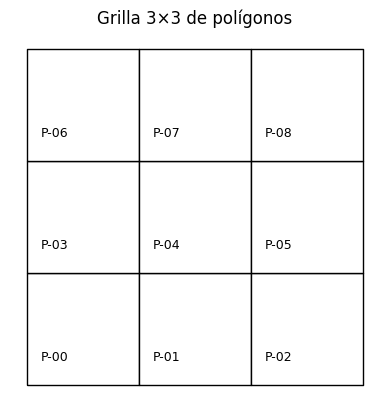

In [5]:
# Visualizar la grilla con etiquetas
ax = gdf.plot(facecolor="w", edgecolor="k")
for x, y, t in zip(
    [p.centroid.x - 0.25 for p in polys],
    [p.centroid.y - 0.25 for p in polys],
    gdf["id"],
):
    plt.text(x, y, t, va="center", ha="center", fontsize=9)
ax.set_axis_off()
ax.set_title("Grilla 3×3 de polígonos", fontsize=12)
plt.show()

### 2.0.1 Contigüidad Rook (torre)

La contigüidad **Rook** requiere que dos polígonos compartan una **arista** completa. Así, P-00 es vecino Rook de P-01 y P-03, pero **no** de P-04 (sólo comparten un vértice).


/var/folders/nc/d5q5pv0177x4vc6_ryc6qwn00000gn/T/ipykernel_5947/1144133730.py:2: FutureWarning: `use_index` defaults to False but will default to True in future. Set True/False directly to control this behavior and silence this warning
  wr = weights.contiguity.Rook.from_dataframe(gdf)


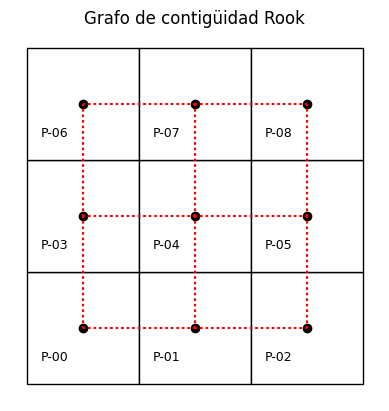

In [6]:
# Construir la matriz de contigüidad Rook
wr = weights.contiguity.Rook.from_dataframe(gdf)

# Visualizar el grafo de vecindad Rook
f, ax = plt.subplots(1, 1, subplot_kw=dict(aspect="equal"))

gdf.plot(facecolor="w", edgecolor="k", ax=ax)
for x, y, t in zip(
    [p.centroid.x - 0.25 for p in polys],
    [p.centroid.y - 0.25 for p in polys],
    gdf["id"],
):
    plt.text(x, y, t, va="center", ha="center", fontsize=9)
wr.plot(gdf, edge_kws=dict(color="r", linestyle=":"), ax=ax)
ax.set_axis_off()
ax.set_title("Grafo de contigüidad Rook", fontsize=12)
plt.show()


In [7]:
# Diccionario de vecinos: clave = observación focal, valor = lista de vecinos
wr.neighbors


{0: [1, 3],
 1: [0, 2, 4],
 2: [1, 5],
 3: [0, 4, 6],
 4: [1, 3, 5, 7],
 5: [8, 2, 4],
 6: [3, 7],
 7: [8, 4, 6],
 8: [5, 7]}

El atributo `neighbors` es un diccionario Python que explota la **naturaleza dispersa** de la matriz: sólo almacena los pares con peso no nulo.

Almacenar sólo los vecinos (en lugar de la matriz completa $n \times n$) reduce la complejidad de memoria de $O(n^2)$ a $O(n \cdot k_{\text{avg}})$, donde $k_{\text{avg}}$ es la cardinalidad promedio.

Podemos también construir la **representación densa** (la matriz completa):


In [8]:
# Representación matricial densa (para inspección, no recomendada para datos grandes)
pandas.DataFrame(*wr.full()).astype(int)


,0,1,2,3,4,5,6,7,8
0,0,1,0,1,0,0,0,0,0
1,1,0,1,0,1,0,0,0,0
2,0,1,0,0,0,1,0,0,0
3,1,0,0,0,1,0,1,0,0
4,0,1,0,1,0,1,0,1,0
5,0,0,1,0,1,0,0,0,1
6,0,0,0,1,0,0,0,1,0
7,0,0,0,0,1,0,1,0,1
8,0,0,0,0,0,1,0,1,0


In [9]:
# Número de entradas no nulas (joins)
print(f"Entradas no nulas: {wr.nonzero}")
print(f"Tamaño total de la matriz: {wr.n}² = {wr.n**2}")
print(f"Porcentaje de dispersión: {100 - wr.pct_nonzero:.1f}%")


Entradas no nulas: 24
Tamaño total de la matriz: 9² = 81
Porcentaje de dispersión: 70.4%


### 2.0.2 Contigüidad Queen (reina)

La contigüidad **Queen** es más inclusiva: basta compartir un **vértice**. Esto agrega, por ejemplo, a P-04 como vecino de P-00 (comparten la esquina superior derecha de P-00).


/var/folders/nc/d5q5pv0177x4vc6_ryc6qwn00000gn/T/ipykernel_5947/1415673762.py:2: FutureWarning: `use_index` defaults to False but will default to True in future. Set True/False directly to control this behavior and silence this warning
  wq = weights.contiguity.Queen.from_dataframe(gdf)


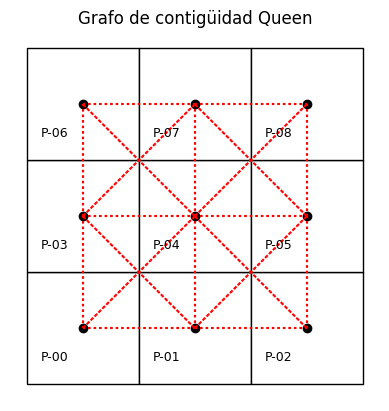

In [11]:
# Construir la matriz de contigüidad Queen
wq = weights.contiguity.Queen.from_dataframe(gdf)

# Visualizar
f, ax = plt.subplots(1, 1, subplot_kw=dict(aspect="equal"))
gdf.plot(facecolor="w", edgecolor="k", ax=ax)
for x, y, t in zip(
    [p.centroid.x - 0.25 for p in polys],
    [p.centroid.y - 0.25 for p in polys],
    gdf["id"],
):
    plt.text(x, y, t, va="center", ha="center", fontsize=9)
wq.plot(gdf, edge_kws=dict(color="r", linestyle=":"), ax=ax)
ax.set_axis_off()
ax.set_title("Grafo de contigüidad Queen", fontsize=12)
plt.show()


In [12]:
# Vecinos Queen
wq.neighbors


{0: [1, 3, 4],
 1: [0, 2, 3, 4, 5],
 2: [1, 4, 5],
 3: [0, 1, 4, 6, 7],
 4: [0, 1, 2, 3, 5, 6, 7, 8],
 5: [1, 2, 4, 7, 8],
 6: [3, 4, 7],
 7: [3, 4, 5, 6, 8],
 8: [4, 5, 7]}

In [13]:
# Pesos asociados a cada par (binario para contigüidad)
wq.weights


{0: [1.0, 1.0, 1.0],
 1: [1.0, 1.0, 1.0, 1.0, 1.0],
 2: [1.0, 1.0, 1.0],
 3: [1.0, 1.0, 1.0, 1.0, 1.0],
 4: [1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0],
 5: [1.0, 1.0, 1.0, 1.0, 1.0],
 6: [1.0, 1.0, 1.0],
 7: [1.0, 1.0, 1.0, 1.0, 1.0],
 8: [1.0, 1.0, 1.0]}

### Atributos clave del objeto `W`

Los objetos de pesos espaciales de `pysal` incluyen atributos útiles:

- **`cardinalities`**: número de vecinos por observación.
- **`histogram`**: distribución de cardinalidades.
- **`s0`**: número total de joins (aristas en el grafo).
- **`pct_nonzero`**: densidad de la matriz (% de entradas no nulas).


In [14]:
# Cardinalidades (grado de cada nodo en el grafo)
print("Cardinalidades:", wq.cardinalities)

# Histograma de cardinalidades
print("\nHistograma (cardinalidad, frecuencia):", wq.histogram)

# Número de joins
print(f"\nNúmero total de joins (s0): {wq.s0}")

# Densidad
print(f"Densidad de la matriz: {wq.pct_nonzero:.2f}%")


Cardinalidades: {0: 3, 1: 5, 2: 3, 3: 5, 4: 8, 5: 5, 6: 3, 7: 5, 8: 3}

Histograma (cardinalidad, frecuencia): [(np.int64(3), np.int64(4)), (np.int64(4), np.int64(0)), (np.int64(5), np.int64(4)), (np.int64(6), np.int64(0)), (np.int64(7), np.int64(0)), (np.int64(8), np.int64(1))]

Número total de joins (s0): 40.0
Densidad de la matriz: 49.38%


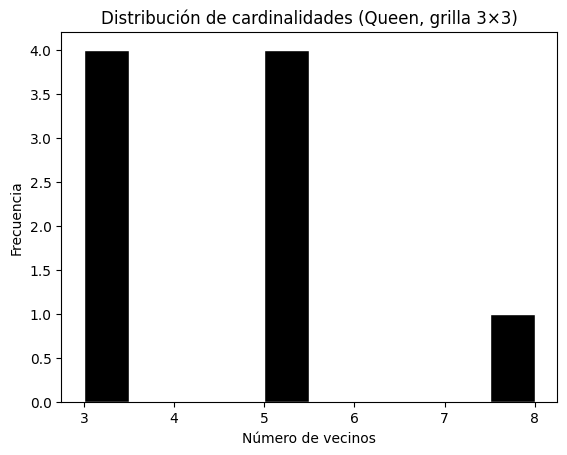

In [ ]:
# Visualizar la distribución de cardinalidades
pandas.Series(wq.cardinalities).plot.hist(color="k", edgecolor="w")
plt.xlabel("Número de vecinos")
plt.ylabel("Frecuencia")
plt.title("Distribución de cardinalidades (Queen, grilla 3×3)")
plt.show()


#### Conexión con teoría de grafos

Una matriz de pesos espaciales es esencialmente una **matriz de adyacencia** de un grafo ponderado:

- Cada **observación** = un **nodo**.
- Cada **peso no nulo** $w_{ij}$ = una **arista** entre $i$ y $j$.
- A veces se le llama **grafo dual** de los datos geográficos.

> **Diferencia clave con series temporales:** las relaciones espaciales son **bidireccionales** (si A es vecino de B, B es vecino de A), mientras que las temporales son unidireccionales.


## 2.1 Pesos desde tablas geográficas reales

Ahora pasemos de la grilla artificial a datos reales. Usaremos los **tracts censales de San Diego, California**.

> Los formatos espaciales comunes (shapefiles, GeoPackage, etc.) **no almacenan topología** explícitamente; sólo definen polígonos como secuencias de vértices. `pysal` usa **índices espaciales** eficientes internamente para extraer las relaciones de vecindad.


In [16]:
# Leer datos de tracts de San Diego
san_diego_tracts = geopandas.read_file("datos/external/sandiego/sandiego_tracts.gpkg"
)


san_diego_tracts.head()

,GEOID,median_age,total_pop,total_pop_white,tt_work,hh_total,hh_female,total_bachelor,median_hh_income,income_gini,...,state,county,tract,area_sqm,pct_rented,pct_hh_female,pct_bachelor,pct_white,sub_30,geometry
0,06073018300,37.1,2590.0,2375.0,1299.0,2590.0,137.0,0.0,62500.0,0.5355,...,06,073,018300,2.876449,0.373913,0.052896,0.000000,0.916988,False,"POLYGON ((-13069450.120 3922380.770, -13069175..."
1,06073018601,41.2,5147.0,4069.0,1970.0,5147.0,562.0,24.0,88165.0,0.4265,...,06,073,018601,4.548797,0.205144,0.109190,0.004663,0.790558,False,"POLYGON ((-13067719.770 3922939.420, -13067631..."
2,06073017601,54.4,5595.0,4925.0,1702.0,5595.0,442.0,34.0,110804.0,0.4985,...,06,073,017601,8.726275,0.279029,0.078999,0.006077,0.880250,False,"POLYGON ((-13058166.110 3907247.690, -13058140..."
3,06073019301,42.3,7026.0,5625.0,3390.0,7026.0,638.0,46.0,100539.0,0.4003,...,06,073,019301,3.519743,0.196512,0.090806,0.006547,0.800598,False,"POLYGON ((-13056896.290 3925255.610, -13056868..."
4,06073018700,21.8,40402.0,30455.0,24143.0,40402.0,2456.0,23.0,41709.0,0.3196,...,06,073,018700,559.150793,0.949887,0.060789,0.000569,0.753799,False,"POLYGON ((-13090788.510 3946435.430, -13090736..."


/var/folders/nc/d5q5pv0177x4vc6_ryc6qwn00000gn/T/ipykernel_5947/2812927786.py:2: FutureWarning: `use_index` defaults to False but will default to True in future. Set True/False directly to control this behavior and silence this warning
  w_queen = weights.contiguity.Queen.from_dataframe(san_diego_tracts)


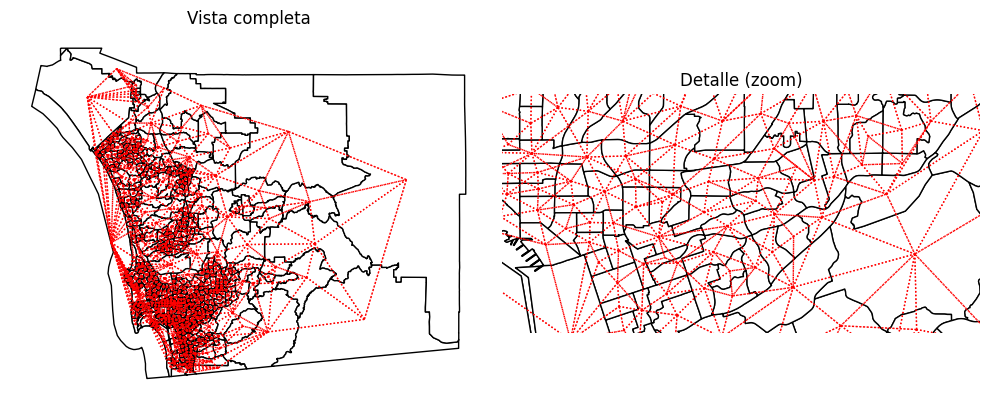

In [17]:
# Construir pesos Queen
w_queen = weights.contiguity.Queen.from_dataframe(san_diego_tracts)

# Visualizar: vista general y detalle
f, axs = plt.subplots(1, 2, figsize=(10, 5))
for i in range(2):
    san_diego_tracts.plot(edgecolor="k", facecolor="w", ax=axs[i])
    w_queen.plot(
        san_diego_tracts,
        ax=axs[i],
        edge_kws=dict(color="r", linestyle=":", linewidth=1),
        node_kws=dict(marker=""),
    )
    axs[i].set_axis_off()

axs[0].set_title("Vista completa")
axs[1].set_title("Detalle (zoom)")
axs[1].axis([-13040000, -13020000, 3850000, 3860000])
plt.tight_layout()
plt.show()

In [18]:
# Propiedades del grafo
print(f"Número de unidades espaciales (n): {w_queen.n}")
print(f"Densidad de la matriz: {w_queen.pct_nonzero:.4f}%")


Número de unidades espaciales (n): 628
Densidad de la matriz: 1.0183%


Observemos que la matriz es **mucho más dispersa** que en la grilla 3×3. Esto es típico de datos reales: la mayoría de los polígonos no son vecinos entre sí.


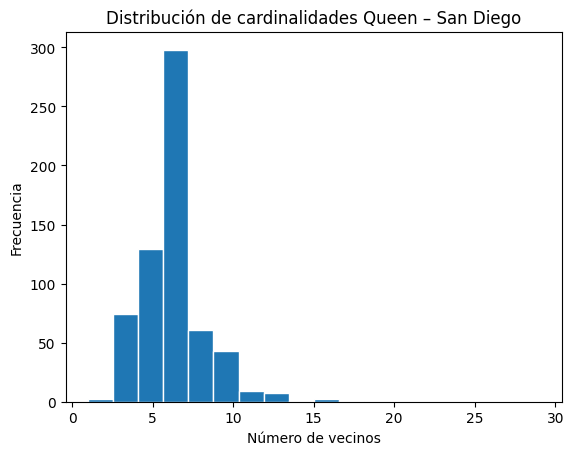

In [19]:
# Distribución de cardinalidades Queen para San Diego
s = pandas.Series(w_queen.cardinalities)
s.plot.hist(bins=s.unique().shape[0], edgecolor="w")
plt.xlabel("Número de vecinos")
plt.ylabel("Frecuencia")
plt.title("Distribución de cardinalidades Queen – San Diego")
plt.show()


/var/folders/nc/d5q5pv0177x4vc6_ryc6qwn00000gn/T/ipykernel_5947/447155580.py:2: FutureWarning: `use_index` defaults to False but will default to True in future. Set True/False directly to control this behavior and silence this warning
  w_rook = weights.contiguity.Rook.from_dataframe(san_diego_tracts)


Densidad Rook: 0.8722%


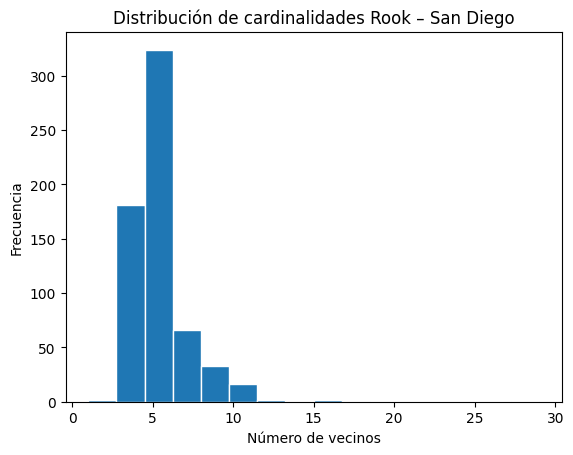

In [20]:
# Comparar con Rook
w_rook = weights.contiguity.Rook.from_dataframe(san_diego_tracts)
print(f"Densidad Rook: {w_rook.pct_nonzero:.4f}%")

s = pandas.Series(w_rook.cardinalities)
s.plot.hist(bins=s.unique().shape[0], edgecolor="w")
plt.xlabel("Número de vecinos")
plt.ylabel("Frecuencia")
plt.title("Distribución de cardinalidades Rook – San Diego")
plt.show()


La distribución Rook se desplaza ligeramente a la izquierda respecto a Queen. Esto tiene sentido: **todo vecino Rook es también vecino Queen**, pero no todo vecino Queen es Rook (algunos sólo comparten un vértice).


## 2.2 Pesos desde superficies (rasters)

Desde la versión 2.4, `pysal` permite construir pesos espaciales a partir de objetos `xarray.DataArray` (datos raster). Esto amplía los análisis que tradicionalmente se usaban sólo para tablas geográficas.

```python
# Ejemplo (requiere rioxarray instalado):
# sao_paulo = rioxarray.open_rasterio("../data/ghsl/ghsl_sao_paulo.tif")
# w_sao_paulo = weights.contiguity.Queen.from_xarray(sao_paulo)
```

El objeto resultante es de tipo `WSP` (versión dispersa del objeto `W`).


# 3. Pesos basados en distancia

Además de contigüidad, podemos definir vecindad como función de la **distancia** entre observaciones. Esto requiere calcular una **matriz de distancias** entre todos los pares, y luego aplicar una **función kernel** para transformar distancias en pesos.

## 3.1 K vecinos más cercanos (KNN)

KNN define el conjunto de vecinos de una observación como sus $k$ observaciones más cercanas. Para polígonos, se usa la distancia entre **centroides**.


In [21]:
# KNN con k=4 para San Diego
wk4 = weights.distance.KNN.from_dataframe(san_diego_tracts, k=4)

# ¿Hay "islas" (nodos sin vecinos)?
print(f"Islas: {wk4.islands}")

# Histograma de cardinalidades
print(f"Histograma: {wk4.histogram}")


Islas: []
Histograma: [(np.int64(4), np.int64(628))]


### Propiedades de KNN

- **No hay islas** por construcción: todo nodo tiene exactamente $k$ vecinos.
- **Cardinalidad uniforme**: todos los nodos tienen el mismo grado de salida ($k$).
- Sin embargo, el grafo **no es necesariamente simétrico**: que A sea vecino de B no implica que B sea vecino de A.

> **Observación para informáticos:** El grafo KNN es un **dígrafo** (grafo dirigido). Si necesitamos simetría, podemos tomar la unión $W \cup W^T$.


## 3.2 Pesos tipo kernel

Los pesos kernel implementan de forma directa la **Primera Ley de Tobler**: *todo está relacionado con todo, pero las cosas cercanas están más relacionadas que las lejanas*. El peso entre $i$ y $j$ es una función decreciente de su distancia.

Los dos parámetros principales son:
1. **Función kernel**: controla la forma de la curva de decaimiento (triangular, gaussiana, etc.).
2. **Ancho de banda (*bandwidth*)**: distancia máxima de influencia; más allá, el peso es 0.


In [22]:
# Kernel con valores por defecto (triangular, ancho de banda fijo)
w_kernel = weights.distance.Kernel.from_dataframe(gdf)

print(f"Función kernel: {w_kernel.function}")
print(f"\nAncho de banda (primeros 5 valores):")
print(w_kernel.bandwidth[0:5])
print(f"\nDensidad: {w_kernel.pct_nonzero:.2f}%")


Función kernel: triangular

Ancho de banda (primeros 5 valores):
[[1.0000001]
 [1.0000001]
 [1.0000001]
 [1.0000001]
 [1.0000001]]

Densidad: 40.74%


### Ancho de banda adaptativo

Un ancho de banda **fijo** puede ser problemático cuando la densidad de observaciones varía geográficamente: zonas densas tendrían muchos vecinos, zonas dispersas muy pocos.

La alternativa es un ancho de banda **adaptativo**: para cada observación, se selecciona un ancho de banda que incluya exactamente a sus $k$ vecinos más cercanos.


In [23]:
# Subconjunto de tracts para visualizar kernels adaptativos
sub_30 = san_diego_tracts.query("sub_30 == True")

# Kernel adaptativo con k=15
w_adaptive = weights.distance.Kernel.from_dataframe(
    sub_30, fixed=False, k=15
)

# Los anchos de banda varían por observación
print("Anchos de banda (primeros 5):")
print(w_adaptive.bandwidth[:5])


Anchos de banda (primeros 5):
[[7065.74020822]
 [3577.22591841]
 [2989.74807871]
 [2891.46196945]
 [3965.08354232]]


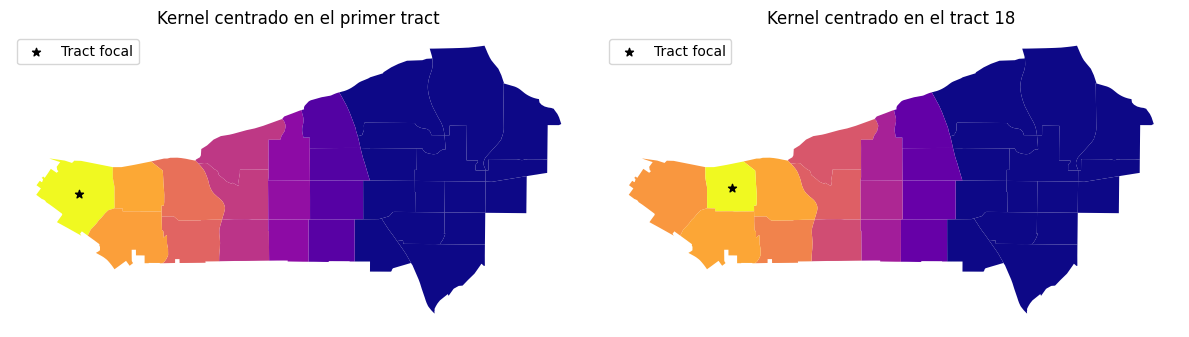

In [24]:
# Visualizar los pesos kernel para dos observaciones focales
full_matrix, ids = w_adaptive.full()

f, ax = plt.subplots(1, 2, figsize=(12, 6), subplot_kw=dict(aspect="equal"))

# Kernel centrado en la primera observación
sub_30.assign(peso_0=full_matrix[0]).plot("peso_0", cmap="plasma", ax=ax[0])
sub_30.iloc[[0], :].centroid.plot(ax=ax[0], marker="*", color="k", label="Tract focal")
ax[0].set_title("Kernel centrado en el primer tract")
ax[0].set_axis_off()
ax[0].legend(loc="upper left")

# Kernel centrado en la 18ª observación
sub_30.assign(peso_18=full_matrix[17]).plot("peso_18", cmap="plasma", ax=ax[1])
sub_30.iloc[[17], :].centroid.plot(ax=ax[1], marker="*", color="k", label="Tract focal")
ax[1].set_title("Kernel centrado en el tract 18")
ax[1].set_axis_off()
ax[1].legend(loc="upper left")

plt.tight_layout()
plt.show()


## 3.3 Bandas de distancia y pesos híbridos

Otra opción: trazar un **círculo de radio fijo** alrededor de cada observación y considerar como vecinos a todos los que caigan dentro del círculo (similar a un *buffer* en SIG).


In [25]:
# Banda de distancia binaria (umbral = 1.5)
w_bdb = weights.distance.DistanceBand.from_dataframe(gdf, 1.5, binary=True)

# Banda de distancia continua (inverso de la distancia)
w_hy = weights.distance.DistanceBand.from_dataframe(gdf, 1.5, binary=False)


/Users/calipsotornasol/Documents/geodata/.venv/lib/python3.11/site-packages/scipy/sparse/_data.py:128: RuntimeWarning: divide by zero encountered in power
  return self._with_data(data ** n)


In [26]:
# Comparar: pesos Queen vs pesos híbridos para el polígono central (4)
print("Queen - pesos del polígono 4:", wq.weights[4])
print("\nHíbrido - pesos del polígono 4:", w_hy.weights[4])


Queen - pesos del polígono 4: [1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0]

Híbrido - pesos del polígono 4: [0.7071067811865475, 1.0, 0.7071067811865475, 1.0, 1.0, 0.7071067811865475, 1.0, 0.7071067811865475]


Observemos que los pesos híbridos **modulan** la importancia de los vecinos: los que comparten sólo un vértice (distancia $\sqrt{2} \approx 1.414$) reciben un peso menor ($1/\sqrt{2} \approx 0.707$) que los que comparten una arista (distancia 1, peso 1).


## 3.4 Distancias sobre la esfera terrestre

Cuando trabajamos con coordenadas **longitud/latitud** (no proyectadas), es crucial considerar la **curvatura de la Tierra**. De lo contrario, las distancias euclidianas pueden ser incorrectas y producir vecindades erróneas.

`pysal` ofrece un radio terrestre para calcular distancias de **gran círculo**:


In [27]:
# Radio de la Tierra en millas
radius = geometry.sphere.RADIUS_EARTH_MILES
print(f"Radio de la Tierra: {radius:.2f} millas")

# KNN-4 ignorando curvatura (INCORRECTO para lon/lat)
knn4_bad = weights.distance.KNN.from_shapefile(
    "../data/texas/texas.shp", k=4
)

# KNN-4 considerando curvatura (CORRECTO)
knn4 = weights.distance.KNN.from_shapefile(
    "../data/texas/texas.shp", k=4, radius=radius
)


Radio de la Tierra: 3958.76 millas


FileNotFoundError: [Errno 2] No such file or directory: '../data/texas/texas.shp'

In [ ]:
# Comparar vecinos de la observación 0
print("Con curvatura (correcto):", knn4[0])
print("Sin curvatura (incorrecto):", knn4_bad[0])


La observación 13 aparece erróneamente como vecina cuando se ignora la curvatura. En la distancia de gran círculo, la observación 3 es la cuarta más cercana.

> **Regla práctica:** Si tus datos están en WGS84 (lon/lat), **siempre** proyéctalos antes de calcular distancias, o usa el parámetro `radius` en `pysal`.


# 4. Pesos de bloque

Los pesos de bloque definen vecindad por **pertenencia a un grupo**. Todas las observaciones del mismo grupo se consideran vecinas entre sí; las de grupos diferentes no son vecinas.

La matriz resultante tiene "bloques" de 1s en la diagonal (de ahí el nombre).


In [ ]:
# Ver las primeras filas del dataset
san_diego_tracts[["GEOID", "state", "county", "tract"]].head()


In [ ]:
# Construir pesos de bloque por condado
w_bl = weights.util.block_weights(
    san_diego_tracts["county"].values,
    ids=san_diego_tracts["GEOID"].values,
)

# Verificar: ¿son vecinos dos tracts del mismo condado?
print("¿06073000201 es vecino de 06073000100?",
      "06073000201" in w_bl["06073000100"])


# 5. Operaciones de conjuntos sobre pesos

Podemos crear matrices de pesos más sofisticadas **combinando** matrices existentes mediante operaciones de conjuntos: unión, intersección, diferencia.

## 5.1 Editar / conectar observaciones desconectadas

Si una observación es una "isla" (sin vecinos por contigüidad), podemos conectarla a su vecino más cercano:


In [ ]:
# Supongamos que la observación 103 es una isla (ejemplo didáctico)
# Encontrar su vecino más cercano con KNN k=1
wk1 = weights.distance.KNN.from_dataframe(san_diego_tracts, k=1)
print(f"Vecino más cercano de 103: {wk1.neighbors[103]}")

# Copiar diccionario de vecinos y agregar la conexión manualmente
neighbors = w_rook.neighbors.copy()
neighbors[103].append(102)
neighbors[102].append(103)

# Construir nuevo objeto W
w_new = weights.W(neighbors)
print(f"\nVecinos actualizados de 103: {w_new[103]}")


## 5.2 Unión de matrices

Una forma más elegante es usar la **unión** de dos matrices de pesos. Dos observaciones son vecinas si lo son en *cualquiera* de las dos matrices originales:


In [ ]:
# Unión de Rook + KNN-1
w_fixed_sets = weights.set_operations.w_union(w_rook, wk1)


# 6. Visualización de operaciones de conjuntos

Comparemos visualmente diferentes grafos de vecindad usando los 32 estados de **México**:


In [ ]:
# Leer datos de México
mx = geopandas.read_file("../data/mexico/mexicojoin.shp")

# Construir distintos tipos de pesos
mx_queen = weights.contiguity.Queen.from_dataframe(mx)         # Queen
mx_knn4 = weights.KNN.from_dataframe(mx, k=4)                  # KNN-4
mx_bw = weights.util.block_weights(mx["INEGI2"].values)         # Bloques por región
mx_union = weights.set_operations.w_union(mx_bw, mx_queen)     # Unión Block+Queen


In [ ]:
# Visualizar los 4 grafos
f, axs = plt.subplots(2, 2, figsize=(10, 10))

# Queen
ax = axs[0, 0]
mx.plot(ax=ax)
mx_queen.plot(mx, edge_kws=dict(linewidth=1, color="orangered"),
              node_kws=dict(marker="*"), ax=ax)
ax.set_axis_off()
ax.set_title("Queen")

# KNN-4
ax = axs[0, 1]
mx.plot(ax=ax)
mx_knn4.plot(mx, edge_kws=dict(linewidth=1, color="orangered"),
             node_kws=dict(marker="*"), ax=ax)
ax.set_axis_off()
ax.set_title("$K$-NN 4")

# Bloques
ax = axs[1, 0]
mx.plot(column="INEGI2", categorical=True, cmap="Pastel2", ax=ax)
mx_bw.plot(mx, edge_kws=dict(linewidth=1, color="orangered"),
           node_kws=dict(marker="*"), ax=ax)
ax.set_axis_off()
ax.set_title("Pesos de bloque")

# Unión
ax = axs[1, 1]
mx.plot(column="INEGI2", categorical=True, cmap="Pastel2", ax=ax)
mx_union.plot(mx, edge_kws=dict(linewidth=1, color="orangered"),
              node_kws=dict(marker="*"), ax=ax)
ax.set_axis_off()
ax.set_title("Queen + Bloques (unión)")

plt.tight_layout()
plt.show()


In [ ]:
# Comparar densidad
print(f"Densidad Block: {mx_bw.pct_nonzero:.2f}%")
print(f"Densidad Queen: {mx_queen.pct_nonzero:.2f}%")


### Observaciones clave

- **Queen vs KNN:** KNN es más disperso en zonas densas (limita a 4 vecinos) y más denso en zonas con pocos polígonos grandes.
- **Block:** Muy denso dentro de cada región, pero **desconectado** entre regiones (5 componentes conexas).
- **Queen + Block (unión):** Combina densidad intra-regional con conexiones inter-regionales → **una sola componente conexa**.

> Muchas técnicas de análisis espacial requieren un grafo **completamente conexo**. La unión es una herramienta útil para lograrlo.


# 7. Caso de uso: detección de fronteras

> ⚠️ Esta sección es más avanzada. Involucra simulación y análisis estadístico.

Las matrices de pesos son útiles por sí mismas para detectar **discontinuidades en los datos**: fronteras donde una variable cambia abruptamente entre áreas vecinas.


In [ ]:
# Visualizar el ingreso mediano por hogar en San Diego
f, ax = plt.subplots(1, 2, figsize=(12, 4))
san_diego_tracts.plot("median_hh_income", ax=ax[0], legend=True)
ax[0].set_axis_off()
ax[0].set_title("Ingreso mediano por hogar")
san_diego_tracts["median_hh_income"].plot.hist(ax=ax[1], bins=30, color="steelblue")
ax[1].set_xlabel("Ingreso ($)")
ax[1].set_title("Distribución del ingreso")
plt.tight_layout()
plt.show()


### Lista de adyacencia

Convertimos el grafo a una **lista de adyacencia** (*adjacency list*), una representación tabular del grafo:


In [ ]:
# Convertir a lista de adyacencia
adjlist = w_rook.to_adjlist()
adjlist.head()


In [ ]:
# Unir información de ingreso para observaciones focal y vecina
adjlist_income = adjlist.merge(
    san_diego_tracts[["median_hh_income"]],
    how="left", left_on="focal", right_index=True,
).merge(
    san_diego_tracts[["median_hh_income"]],
    how="left", left_on="neighbor", right_index=True,
    suffixes=("_focal", "_neighbor"),
)

# Calcular diferencia de ingreso entre vecinos
adjlist_income["diff"] = (
    adjlist_income["median_hh_income_focal"]
    - adjlist_income["median_hh_income_neighbor"]
)

adjlist_income.head()


### Comparar diferencias: vecinos vs. no-vecinos

Si el ingreso sigue un **patrón espacial** (autocorrelación espacial), las diferencias entre vecinos deberían ser menores que las diferencias entre no-vecinos:


In [ ]:
# Diferencias entre TODOS los pares
all_pairs = numpy.subtract.outer(
    san_diego_tracts["median_hh_income"].values,
    san_diego_tracts["median_hh_income"].values,
)

# Complemento de la matriz de pesos (1 donde no hay vecindad)
complement_wr = 1 - w_rook.sparse.toarray()

# Diferencias entre no-vecinos
non_neighboring_diffs = (complement_wr * all_pairs).flatten()

# Comparar distribuciones
f = plt.figure(figsize=(12, 3))
plt.hist(non_neighboring_diffs, color="lightgrey", edgecolor="k",
         density=True, bins=50, label="No vecinos")
plt.hist(adjlist_income["diff"], color="salmon", edgecolor="orangered",
         linewidth=3, density=True, histtype="step", bins=50, label="Vecinos")
seaborn.despine()
plt.ylabel("Densidad")
plt.xlabel("Diferencia en ingreso ($)")
plt.legend()
plt.title("Distribución de diferencias de ingreso: vecinos vs. no vecinos")
plt.show()


La distribución de los **vecinos** (rojo) es más concentrada alrededor de cero → las áreas cercanas tienden a tener ingresos similares. Esto es **autocorrelación espacial positiva**, que estudiaremos en capítulos posteriores.

### Fronteras más extremas

Podemos identificar los pares de vecinos con las diferencias más pronunciadas:


In [ ]:
# Las 5 diferencias más extremas
extremes = adjlist_income.sort_values("diff", ascending=False).head()
extremes


### Simulación para evaluar significancia

¿Son estas diferencias extremas realmente significativas, o podrían ocurrir por azar? Usamos una **estrategia de aleatorización de mapas**: mezclamos los valores de ingreso aleatoriamente y recalculamos las diferencias.


In [ ]:
# Simulación (puede tomar unos segundos)
n_simulations = 500  # Reducido para agilizar; usar 1000 para mayor precisión
simulated_diffs = numpy.empty((len(adjlist), n_simulations))

for i in range(n_simulations):
    random_income = (
        san_diego_tracts[["median_hh_income"]]
        .sample(frac=1, replace=False)
        .reset_index()
    )
    adjlist_random = adjlist.merge(
        random_income, left_on="focal", right_index=True
    ).merge(
        random_income, left_on="neighbor", right_index=True,
        suffixes=("_focal", "_neighbor"),
    )
    simulated_diffs[:, i] = (
        adjlist_random["median_hh_income_focal"]
        - adjlist_random["median_hh_income_neighbor"]
    )


In [ ]:
# Comparar simulaciones vs. observado
f = plt.figure(figsize=(12, 3))
plt.hist(adjlist_income["diff"], color="salmon", bins=50,
         density=True, alpha=1, linewidth=4)
[plt.hist(sim, histtype="step", color="k", alpha=0.01,
          linewidth=1, bins=50, density=True)
 for sim in simulated_diffs.T]
plt.hist(adjlist_income["diff"], histtype="step", edgecolor="orangered",
         bins=50, density=True, linewidth=2)
seaborn.despine()
plt.ylabel("Densidad")
plt.xlabel("Diferencia en ingreso ($)")
plt.title("Observado (rojo) vs. simulaciones aleatorias (negro)")
plt.show()


In [ ]:
# Identificar fronteras estadísticamente significativas (percentil 0.5% y 99.5%)
pooled_diffs = simulated_diffs.flatten()
lower, median, upper = numpy.percentile(pooled_diffs, q=(0.5, 50, 99.5))

outside = (adjlist_income["diff"] < lower) | (adjlist_income["diff"] > upper)

print("Fronteras en el 1% más extremo:")
adjlist_income[outside]


La observación **473** aparece repetidamente, lo que sugiere que es un *outlier* espacial: su ingreso es extremadamente diferente al de todos sus vecinos. Este tipo de comparación generalizada entre vecinos se formaliza en el capítulo de **autocorrelación espacial local**.


# 8. Conclusión

Los pesos espaciales son **fundamentales** para representar relaciones geográficas en ciencia de datos. Sus puntos clave:

| Concepto | Descripción |
|----------|-------------|
| **Contigüidad** | Rook (aristas), Queen (vértices), Bishop (sólo vértices) |
| **Distancia** | KNN, Kernel, Bandas de distancia |
| **Bloques** | Por membresía en grupo |
| **Operaciones de conjuntos** | Unión, intersección, diferencia de matrices |

### Desde la perspectiva de informática:

- Son **matrices dispersas** → representación eficiente con CSR/CSC.
- Son **grafos** → se pueden analizar con algoritmos de componentes conexas, centralidad, caminos más cortos, etc.
- Interoperan con **NetworkX**, **scipy.sparse**, y el ecosistema científico de Python.
- Son la base de **modelos espaciales** en machine learning y estadística.


# 9. Preguntas

1. **Contigüidad Bishop:** Usando las matrices Rook y Queen de San Diego y la función `weights.set_operations.w_difference`, ¿existen observaciones con contigüidad Bishop (comparten sólo vértices, no aristas)?

2. **Comparación de cardinalidades:** Considerando Queen, Block y la unión Queen+Block:
   - ¿Cuál tiene la cardinalidad promedio más alta?
   - ¿Cuál tiene más entradas no nulas?
   - ¿Por qué?

3. **Componentes conexas:** Un grafo es *conexo* si existe un camino entre cualquier par de nodos.
   - ¿Cuántas componentes conexas tiene el grafo Queen de San Diego?
   - Con KNN $k=1$, ¿cuántas componentes hay?
   - Incrementa $k$ hasta obtener 1 componente. Graficá la relación $k$ vs. `n_components`.
   - ¿A qué valor de $k$ se alcanza 1 componente?

4. **Dispersión:** ¿Cuál de los grafos vistos en este capítulo tiene la estructura más dispersa?

5. **Grillas hexagonales:** Compara `lat2W` y `hexLat2W` para tamaños (3,3), (6,6) y (9,9):
   - ¿Cuál tiene mayor cardinalidad promedio?
   - ¿Cuál tiene mayor variación en el número de vecinos?
   - ¿Por qué no existe la opción `rook=True` en `hexLat2W`?

6. **Diagramas de Voronoi:** Construye el diagrama de Voronoi para los centroides de los estados de México y compara las conexiones con el grafo Queen.

7. **Interoperabilidad:** 
   - Convierte la matriz Queen+Block de México a un grafo `networkx` y calcula la centralidad de eigenvector.
   - Calcula el número de componentes conexas de los pesos Block con `scipy.sparse.csgraph.connected_components`.

8. **In-degree vs Out-degree en KNN:** Para KNN $k=6$ de San Diego:
   - Calcula el in-degree de cada observación.
   - Haz un histograma del in-degree normalizado.
   - ¿Disminuye la "hubbiness" al aumentar $k$?

9. **Vecindarios de San Diego:** Para el dataset `san_diego_neighborhoods`:
   - Construye los pesos Queen. ¿Cuántas componentes conexas hay?
   - Encuentra el menor $k$ para que el grafo KNN sea conexo.
   - ¿Cuántos "puentes" hay entre las componentes norte y sur?


# 10. Siguientes pasos

Para profundizar en redes y matrices de pesos espaciales:

- **Anselin & Rey**, *Modern Spatial Econometrics in Practice*, Capítulo 3.
- **Uitermark & van Meeteren** (2021), "Geographical Network Analysis", *TESG* 112: 337-350.
- **Documentación de PySAL:** [https://pysal.org/libpysal/](https://pysal.org/libpysal/)
- **NetworkX:** [https://networkx.org/](https://networkx.org/) – para análisis de grafos general.

---

*Notebook adaptado para uso académico. Material original con licencia CC BY-NC-ND 4.0 por Rey, Arribas-Bel & Wolf.*
